# Clasificación de Texturas
Aplicación capaz de diferenciar superficies dentro de una imagen (césped, tierra, cemento, asfalto), aplicando principios similares a los utilizados en clasificación de imágenes satelitales.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (15, 6)
print("librerías cargadas.")

librerías cargadas.


## Paso 1: Cargar la imagen con distintas superficies

selecionar imagen


Saving reflejo-paisaje-simetria-734x489.jpg to reflejo-paisaje-simetria-734x489 (1).jpg
dimensiones: 734x489 píxeles, 3 canales


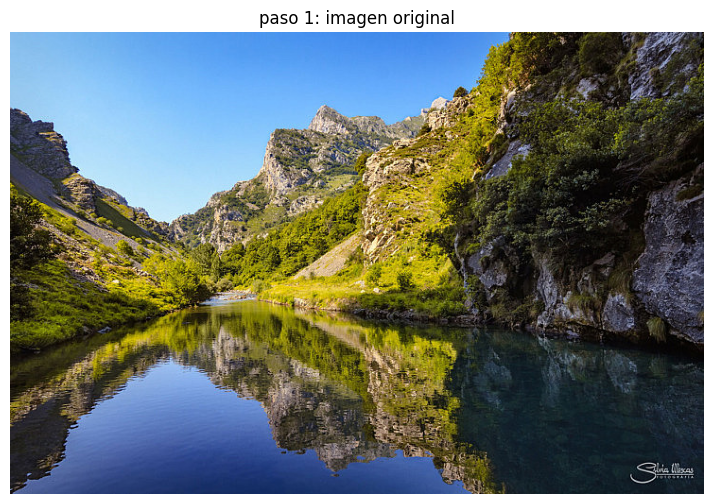

In [9]:
from google.colab import files

print("selecionar imagen")
uploaded = files.upload()

for fn in uploaded.keys():
    img_bgr = cv2.imread(fn)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"dimensiones: {img_rgb.shape[1]}x{img_rgb.shape[0]} píxeles, {img_rgb.shape[2]} canales")

plt.imshow(img_rgb)
plt.title('paso 1: imagen original')
plt.axis('off')
plt.show()

## Paso 2: Convertir al espacio de color HSV
En clasificación satelital se usan distintas bandas espectrales. De forma similar, convertimos la imagen a HSV (Tono, Saturación, Valor) porque separa mejor las superficies que el RGB.

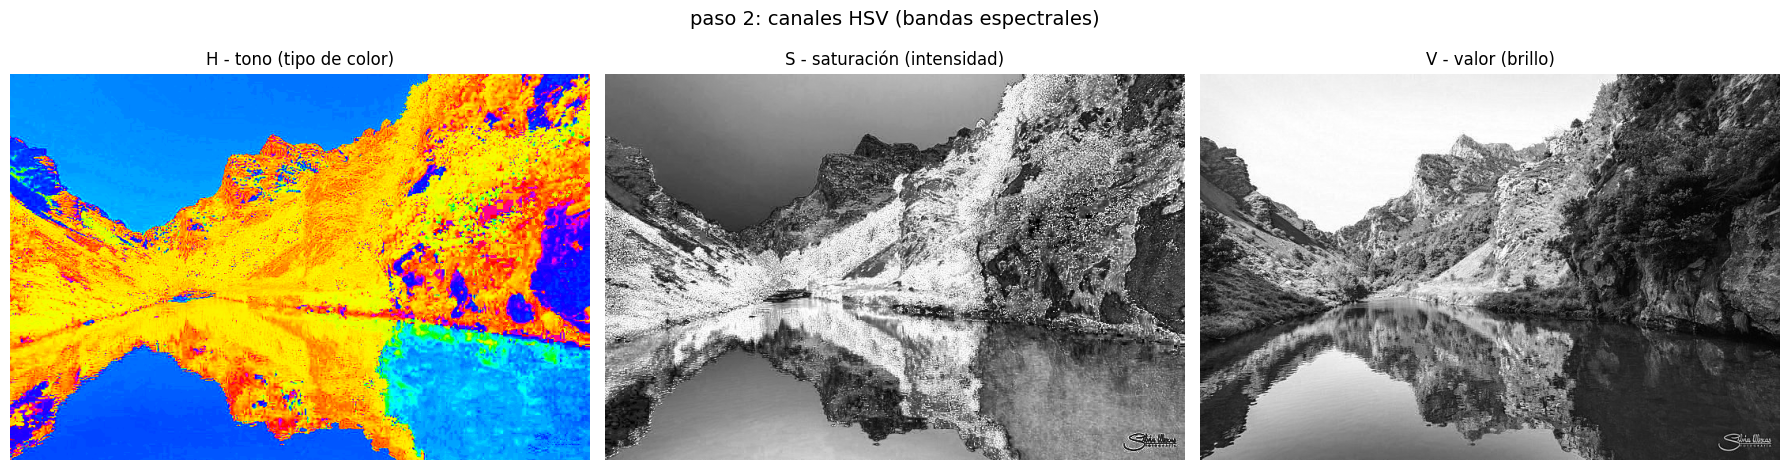

In [3]:
# convertir a HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].imshow(img_hsv[:, :, 0], cmap='hsv')
axs[0].set_title('H - tono (tipo de color)')
axs[0].axis('off')

axs[1].imshow(img_hsv[:, :, 1], cmap='gray')
axs[1].set_title('S - saturación (intensidad)')
axs[1].axis('off')

axs[2].imshow(img_hsv[:, :, 2], cmap='gray')
axs[2].set_title('V - valor (brillo)')
axs[2].axis('off')

plt.suptitle('paso 2: canales HSV (bandas espectrales)', fontsize=14)
plt.tight_layout()
plt.show()

## Paso 3: Preparar los datos para la clasificación
Cada píxel se convierte en un punto con 3 coordenadas (R, G, B). El algoritmo K-Means agrupa los píxeles similares en clusters (clases de superficie).

In [4]:
# aplanar la imagen: de (alto x ancho x 3) a (total_pixeles x 3)
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

print(f"forma original de la imagen: {img_rgb.shape}")
print(f"forma aplanada para K-Means: {pixel_values.shape}")
print(f"total de píxeles a clasificar: {pixel_values.shape[0]:,}")
print(f"\nprimeros 5 píxeles (valores R, G, B):")
print(pixel_values[:5])

forma original de la imagen: (489, 734, 3)
forma aplanada para K-Means: (358926, 3)
total de píxeles a clasificar: 358,926

primeros 5 píxeles (valores R, G, B):
[[131. 189. 237.]
 [131. 189. 237.]
 [131. 189. 237.]
 [131. 189. 237.]
 [131. 189. 237.]]


## Paso 4: Aplicar K-Means para segmentar superficies
K-Means agrupa todos los píxeles en K clases según la similitud de sus colores. Esto es equivalente a una clasificación no supervisada en teledetección.

In [5]:
# número de superficies a diferenciar
k = 4

# criterios de parada del algoritmo
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# ejecutar K-Means
_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

print(f"se encontraron {k} clases de superficies")
print(f"\ncentros de cada clase (color promedio R, G, B):")
for i in range(k):
    r, g, b = centers[i]
    count = np.sum(labels == i)
    pct = count / len(labels) * 100
    print(f"  clase {i+1}: R={r:.0f}, G={g:.0f}, B={b:.0f} → {pct:.1f}% de la imagen")

se encontraron 4 clases de superficies

centros de cada clase (color promedio R, G, B):
  clase 1: R=133, G=183, B=235 → 22.3% de la imagen
  clase 2: R=75, G=83, B=108 → 16.0% de la imagen
  clase 3: R=155, G=140, B=50 → 19.3% de la imagen
  clase 4: R=39, G=39, B=27 → 42.4% de la imagen


## Paso 5: Reconstruir la imagen clasificada
Cada píxel se reemplaza por el color promedio de su clase, generando un mapa de superficies.

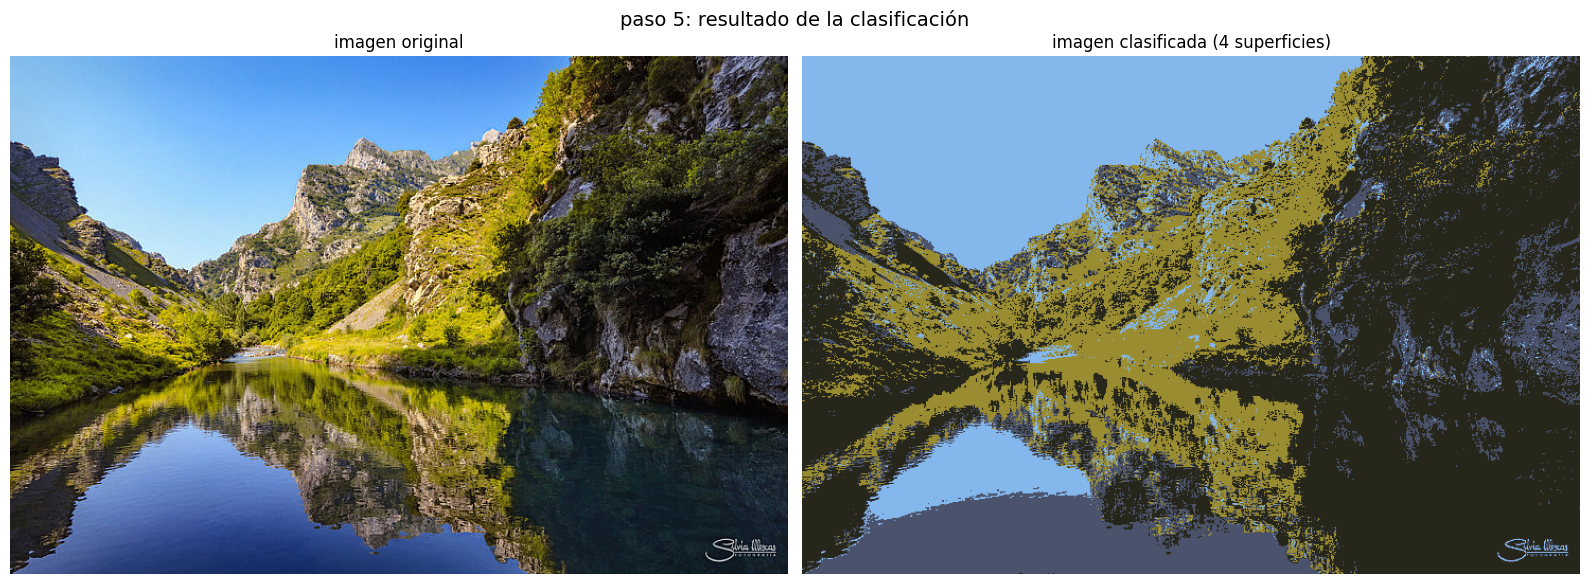

In [6]:
# reemplazar cada pixel por el color de su centro
centers_uint8 = np.uint8(centers)
segmented_data = centers_uint8[labels.flatten()]
img_clasificada = segmented_data.reshape(img_rgb.shape)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_clasificada)
plt.title(f'imagen clasificada ({k} superficies)')
plt.axis('off')

plt.suptitle('paso 5: resultado de la clasificación', fontsize=14)
plt.tight_layout()
plt.show()

## Paso 6: Visualizar cada superficie por separado
Se aísla cada clase mostrando solo los píxeles que pertenecen a esa superficie y calculando el área que ocupa.

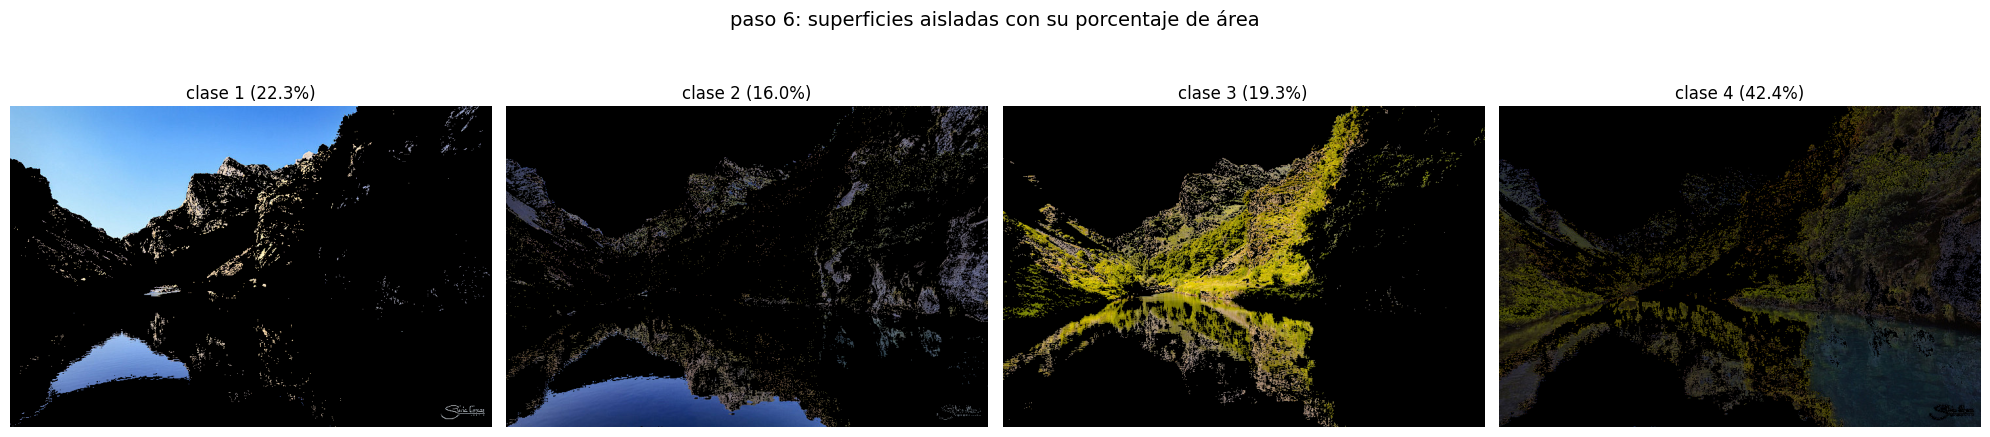

In [7]:
fig, axs = plt.subplots(1, k, figsize=(5*k, 5))

for i in range(k):
    # crear máscara para esta clase
    mask = (labels.flatten() == i)

    # aislar los píxeles originales de esta superficie
    clase_pixels = np.zeros_like(pixel_values)
    clase_pixels[mask] = pixel_values[mask]
    clase_img = clase_pixels.reshape(img_rgb.shape).astype(np.uint8)

    # calcular porcentaje del área
    area_pct = np.sum(mask) / len(labels) * 100

    axs[i].imshow(clase_img)
    axs[i].set_title(f'clase {i+1} ({area_pct:.1f}%)')
    axs[i].axis('off')

plt.suptitle('paso 6: superficies aisladas con su porcentaje de área', fontsize=14)
plt.tight_layout()
plt.show()

## Paso 7: Mapa de clasificación con colores diferenciados
Se asigna un color único a cada superficie para visualizar claramente la distribución de las texturas.

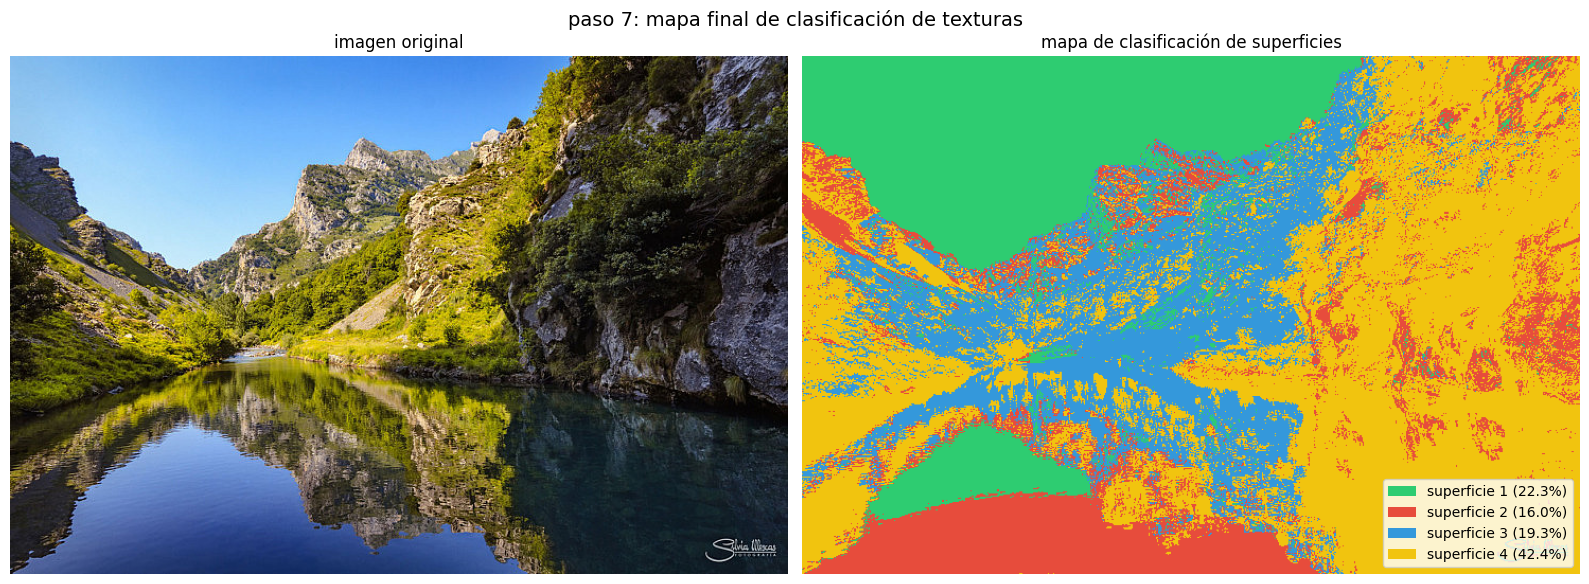

In [8]:
# colores para el mapa de clasificación
colores_mapa = np.array([
    [46, 204, 113],   # verde
    [231, 76, 60],    # rojo
    [52, 152, 219],   # azul
    [241, 196, 15],   # amarillo
], dtype=np.uint8)

# crear mapa coloreado
mapa = colores_mapa[labels.flatten()]
mapa_img = mapa.reshape(img_rgb.shape)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mapa_img)
plt.title('mapa de clasificación de superficies')
plt.axis('off')

# leyenda
nombres = ['superficie 1', 'superficie 2', 'superficie 3', 'superficie 4']
patches = [plt.Rectangle((0,0),1,1, fc=colores_mapa[i]/255) for i in range(k)]
areas = [np.sum(labels.flatten() == i) / len(labels) * 100 for i in range(k)]
legend_labels = [f'{nombres[i]} ({areas[i]:.1f}%)' for i in range(k)]
plt.legend(patches, legend_labels, loc='lower right', fontsize=10)

plt.suptitle('paso 7: mapa final de clasificación de texturas', fontsize=14)
plt.tight_layout()
plt.show()